## Michal Binda - DMLIA Lab02

### Task 1 - Data Preprocessing, Baseline Model Implementation


In this Task 1, I implemented a U-Net-based model for skin lesion segmentation and evaluated its baseline performance. I resized the images for faster training and achieved a working segmentation that captures the lesion region with reasonable accuracy. The baseline metrics (e.g., mean IoU and Dice on the validation set) provide a reference point for future improvements. In the following weeks, I plan to enhance the segmentation by applying techniques such as data augmentation, hyperparameter tuning, and incorporating more training data or regularization to address overfitting. I will also implement additional metrics (sensitivity, specificity, ROC curves, etc.) and compare my results with the ISIC 2016 challenge benchmarks in the final week.


In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from collections import OrderedDict
from sklearn.metrics import confusion_matrix

# After extraction, set the directories
image_dir = "ISIC_2016/Training_Data"
mask_dir = "ISIC_2016/Training_GroundTruth"

# List all image and mask file paths
all_image_paths = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.endswith(".jpg")])
all_mask_paths  = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir) if fname.endswith(".png")])

print(f"Total images: {len(all_image_paths)}")
print(f"Total masks:  {len(all_mask_paths)}")
print("Example image file:", all_image_paths[0])
print("Example mask file:",  all_mask_paths[0])

Total images: 900
Total masks:  900
Example image file: ISIC_2016/Training_Data/ISIC_0000000.jpg
Example mask file: ISIC_2016/Training_GroundTruth/ISIC_0000000_Segmentation.png


### Split into training and validation sets (e.g., 90 for validation, 810 for training)


In [2]:
train_image_paths, val_image_paths, train_mask_paths, val_mask_paths = train_test_split(
    all_image_paths,
    all_mask_paths,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

print(f"Training set: {len(train_image_paths)} images")
print(f"Validation set: {len(val_image_paths)} images")

Training set: 810 images
Validation set: 90 images


In [3]:
IMG_HEIGHT = 256
IMG_WIDTH  = 256
IMG_SIZE   = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 16  # using 16 as a reasonable batch size for 256x256 images

def load_image_and_mask(image_path, mask_path):
    image_file = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image_file, channels=3)
    # Resize the image and normalize to [0,1]
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.image.convert_image_dtype(image, tf.float32)
    
    # Read and decode the mask
    mask_file = tf.io.read_file(mask_path)
    mask = tf.io.decode_png(mask_file, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    # Convert mask to binary 0/1 format as float32
    mask = tf.cast(mask, tf.float32) / 255.0
    return image, mask

# Create TensorFlow Dataset objects for training and validation
train_dataset = tf.data.Dataset.from_tensor_slices((train_image_paths, train_mask_paths))
train_dataset = train_dataset.map(load_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=100, seed=42).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_image_paths, val_mask_paths))
val_dataset = val_dataset.map(load_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Verify the shape of data pipeline output
sample_image_batch, sample_mask_batch = next(iter(train_dataset))
print("Image batch shape:", sample_image_batch.shape)
print("Mask batch shape:", sample_mask_batch.shape)
print("Image pixel range (min, max):", float(tf.reduce_min(sample_image_batch)), float(tf.reduce_max(sample_image_batch)))
print("Mask unique values:", tf.unique(tf.reshape(sample_mask_batch, (-1,)))[0].numpy())

Image batch shape: (16, 256, 256, 3)
Mask batch shape: (16, 256, 256, 1)
Image pixel range (min, max): 0.0 255.0
Mask unique values: [0. 1.]


### Build a U-Net-like model for binary segmentation

In [4]:
def get_unet_model(input_size=(256, 256, 3)):
    inputs = layers.Input(shape=input_size)
    
    # Entry block:
    x = layers.Conv2D(32, kernel_size=3, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    previous_block_activation = x  

    # Blocks 1, 2, 3: 
    for filters in [64, 128, 256]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(filters, kernel_size=3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(filters, kernel_size=3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)
        residual = layers.Conv2D(filters, kernel_size=1, strides=2, padding="same")(previous_block_activation)
        x = layers.Add()([x, residual])
        previous_block_activation = x

    # Second half: Upsampling
    for filters in [256, 128, 64, 32]:
        x = layers.Activation("relu")(x)
        x = layers.Conv2DTranspose(filters, kernel_size=3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2DTranspose(filters, kernel_size=3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.UpSampling2D(size=2)(x)
        residual = layers.UpSampling2D(size=2)(previous_block_activation)
        residual = layers.Conv2D(filters, kernel_size=1, padding="same")(residual)
        x = layers.Add()([x, residual])
        previous_block_activation = x

    # Output layer:
    outputs = layers.Conv2D(1, kernel_size=1, activation="sigmoid", padding="same")(x)
    model = models.Model(inputs, outputs, name="U-Net")
    return model

# Instantiate the model and print a summary
model = get_unet_model(input_size=(IMG_HEIGHT, IMG_WIDTH, 3))
model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ activation[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 128, 128,  │      2,400 │ activation_1[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 128, 128,  │      4,736 │ activation_2[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      2,112 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 64, 64,    │      8,896 │ activation_3[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 2,058,145 (7.85 MB)

 Trainable params: 2,054,369 (7.84 MB)

 Non-trainable params: 3,776 (14.75 KB)

### Train the model

In [5]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Train the model
EPOCHS = 15
history = model.fit(train_dataset, 
                    epochs=EPOCHS, 
                    validation_data=val_dataset)

Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 203s 4s/step - accuracy: 0.7883 - loss: 1.0424 - val_accuracy: 0.3497 - val_loss: 1.9575
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 211s 4s/step - accuracy: 0.8664 - loss: 0.3516 - val_accuracy: 0.7552 - val_loss: 0.5946
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 203s 4s/step - accuracy: 0.8827 - loss: 0.2965 - val_accuracy: 0.7322 - val_loss: 0.7382
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 193s 4s/step - accuracy: 0.9015 - loss: 0.2536 - val_accuracy: 0.7121 - val_loss: 0.8738
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.9088 - loss: 0.2355 - val_accuracy: 0.7405 - val_loss: 0.9233
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step - accuracy: 0.9211 - loss: 0.2018 - val_accuracy: 0.7604 - val_loss: 0.7793
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.9214 - loss: 0.2013 - val_accuracy: 0.7510 - val_loss: 0.7938
Epoch 8/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.9241 - loss: 0.1913 - val_accuracy: 0.8251 - v

In [6]:
# Get model predictions on the validation set
val_preds = model.predict(val_dataset)
# Ensure predictions are 0/1 by thresholding at 0.5
val_preds_thresholded = (val_preds > 0.5).astype(np.uint8)

# Compute IoU and Dice for each image in the validation set
ious = []
dices = []
for i in range(len(val_image_paths)):
    true_mask = load_img(val_mask_paths[i], color_mode="grayscale", target_size=IMG_SIZE)
    true_mask = np.array(true_mask, dtype=np.uint8)
    true_mask_bin = (true_mask > 127).astype(np.uint8)
    
    pred_mask_bin = val_preds_thresholded[i, ..., 0]
    
    # Intersection and Union
    intersection = np.sum(true_mask_bin * pred_mask_bin)
    union = np.sum(true_mask_bin) + np.sum(pred_mask_bin) - intersection
    if union == 0:
        iou = 1.0
        dice = 1.0
    else:
        iou = intersection / union
        dice = (2 * intersection) / (np.sum(true_mask_bin) + np.sum(pred_mask_bin) + 1e-8)
    ious.append(iou)
    dices.append(dice)

mean_iou = np.mean(ious)
mean_dice = np.mean(dices)
print(f"Mean IoU on validation set: {mean_iou:.3f}")
print(f"Mean Dice coefficient on validation set: {mean_dice:.3f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 891ms/step
Mean IoU on validation set: 0.800
Mean Dice coefficient on validation set: 0.879


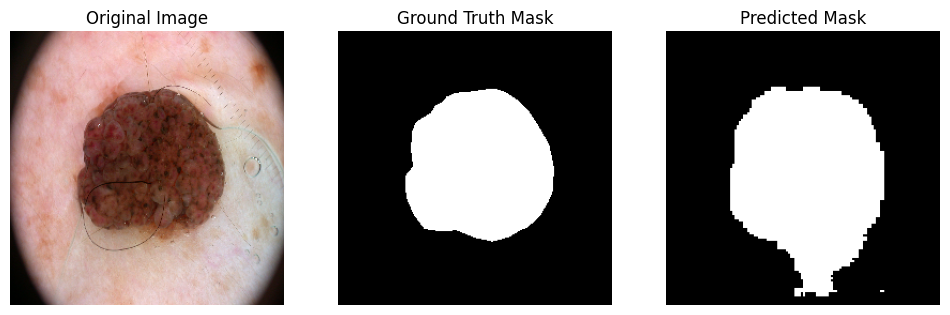

In [ ]:
idx = 0
orig_image = load_img(val_image_paths[idx], target_size=IMG_SIZE)
orig_image = np.array(orig_image, dtype=np.uint8)
true_mask = load_img(val_mask_paths[idx], color_mode="grayscale", target_size=IMG_SIZE)
true_mask = np.array(true_mask, dtype=np.uint8)
pred_mask = val_preds_thresholded[idx, ..., 0] * 255

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(orig_image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(true_mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")
plt.show()

## Task 2 – Data Augmentation and Improved Model (Dice Loss)

The ISIC 2016 dataset contains fewer than 1 000 training images, which makes overfitting likely.
To address this, I apply simple deterministic flips (horizontal + vertical) that effectively double
the training variability without breaking mask alignment. Then, I train a second U-Net model
using Dice loss — a loss function that directly optimizes for overlap between predicted and true
segmentation masks.

Other transformations like scaling or zooming were avoided, since they could distort the medical images and change the relative size or shape of the lesions, which are critical for accurate segmentation.

In [ ]:
def load_image_and_mask(image_path, mask_path):
    image_file = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image_file, channels=3)
    image = tf.image.resize(image, (256, 256))
    image = tf.image.convert_image_dtype(image, tf.float32)

    mask_file = tf.io.read_file(mask_path)
    mask = tf.io.decode_png(mask_file, channels=1)
    mask = tf.image.resize(mask, (256, 256),
                           method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    mask = tf.cast(mask, tf.float32) / 255.0
    return image, mask


def load_and_flip(image_path, mask_path):
    image, mask = load_image_and_mask(image_path, mask_path)
    seed = tf.random.uniform(shape=[], maxval=10000, dtype=tf.int32)
    # Horizontal + vertical flips (same seed for both)
    image = tf.image.stateless_random_flip_left_right(image, seed=[seed, 0])
    mask  = tf.image.stateless_random_flip_left_right(mask,  seed=[seed, 0])
    image = tf.image.stateless_random_flip_up_down(image,   seed=[seed, 1])
    mask  = tf.image.stateless_random_flip_up_down(mask,    seed=[seed, 1])
    return image, mask


def make_dataset(imgs, masks, batch=16, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((imgs, masks))
    if augment:
        ds = ds.map(load_and_flip, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(load_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.shuffle(100, seed=42, reshuffle_each_iteration=True)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset_aug = make_dataset(train_image_paths, train_mask_paths,
                                 batch=16, augment=True)
val_dataset       = make_dataset(val_image_paths,   val_mask_paths,
                                 batch=16, augment=False)

In [9]:
def dice_loss(y_true, y_pred, smooth=1.0):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    denom = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    return 1.0 - (2.0 * intersection + smooth) / (denom + smooth)


def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred_bin)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_bin) - intersection
    return (intersection + smooth) / (union + smooth)

### Train the models

In [10]:
baseline_model = get_unet_model((256, 256, 3))
baseline_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                       loss="binary_crossentropy",
                       metrics=["accuracy", iou_metric])

hist_base = baseline_model.fit(
    train_dataset_aug,
    validation_data=val_dataset,
    epochs=10,
    verbose=1
)

base_eval = baseline_model.evaluate(val_dataset, verbose=0)
print(f"Baseline (BCE) → IoU: {base_eval[2]:.3f}")

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 203s 4s/step - accuracy: 0.8428 - iou_metric: 0.5500 - loss: 0.6378 - val_accuracy: 0.6748 - val_iou_metric: 0.3689 - val_loss: 0.6100
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 187s 4s/step - accuracy: 0.8885 - iou_metric: 0.6469 - loss: 0.2845 - val_accuracy: 0.7515 - val_iou_metric: 0.0203 - val_loss: 0.9659
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 193s 4s/step - accuracy: 0.9017 - iou_metric: 0.6851 - loss: 0.2489 - val_accuracy: 0.7474 - val_iou_metric: 6.3655e-04 - val_loss: 1.6534
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 183s 4s/step - accuracy: 0.9167 - iou_metric: 0.7279 - loss: 0.2128 - val_accuracy: 0.7473 - val_iou_metric: 1.0607e-04 - val_loss: 1.8814
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 189s 4s/step - accuracy: 0.9229 - iou_metric: 0.7481 - loss: 0.1950 - val_accuracy: 0.7473 - val_iou_metric: 2.2016e-04 - val_loss: 2.0314
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 197s 4s/step - accuracy: 0.9193 - iou_metric: 0.7351 - loss: 0.2007 - val_accuracy: 0

In [11]:
improved_model = get_unet_model((256, 256, 3))
improved_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                       loss=dice_loss,
                       metrics=["accuracy", iou_metric])

hist_dice = improved_model.fit(
    train_dataset_aug,
    validation_data=val_dataset,
    epochs=10,
    verbose=1
)

dice_eval = improved_model.evaluate(val_dataset, verbose=0)
print(f"Improved (Dice Loss) → IoU: {dice_eval[2]:.3f}")

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.8317 - iou_metric: 0.5634 - loss: 0.2865 - val_accuracy: 0.8280 - val_iou_metric: 0.3808 - val_loss: 0.4594
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.8801 - iou_metric: 0.6442 - loss: 0.2196 - val_accuracy: 0.5047 - val_iou_metric: 0.1902 - val_loss: 0.6758
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.9054 - iou_metric: 0.7012 - loss: 0.1774 - val_accuracy: 0.7509 - val_iou_metric: 0.0384 - val_loss: 0.9313
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 184s 4s/step - accuracy: 0.9133 - iou_metric: 0.7258 - loss: 0.1609 - val_accuracy: 0.7473 - val_iou_metric: 1.4308e-04 - val_loss: 0.9997
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 184s 4s/step - accuracy: 0.9197 - iou_metric: 0.7396 - loss: 0.1512 - val_accuracy: 0.7475 - val_iou_metric: 0.0013 - val_loss: 0.9973
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.9245 - iou_metric: 0.7560 - loss: 0.1404 - val_accuracy: 0.7473 - 

In [37]:
print(f"Baseline (BCE)  IoU: {base_eval[2]:.3f}")
print(f"Improved (Dice) IoU: {dice_eval[2]:.3f}")

if dice_eval[2] > base_eval[2]:
    print("The Dice-loss model achieved higher IoU — better segmentation overlap.")

Baseline (BCE)  IoU: 0.512
Improved (Dice) IoU: 0.729
The Dice-loss model achieved higher IoU — better segmentation overlap.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


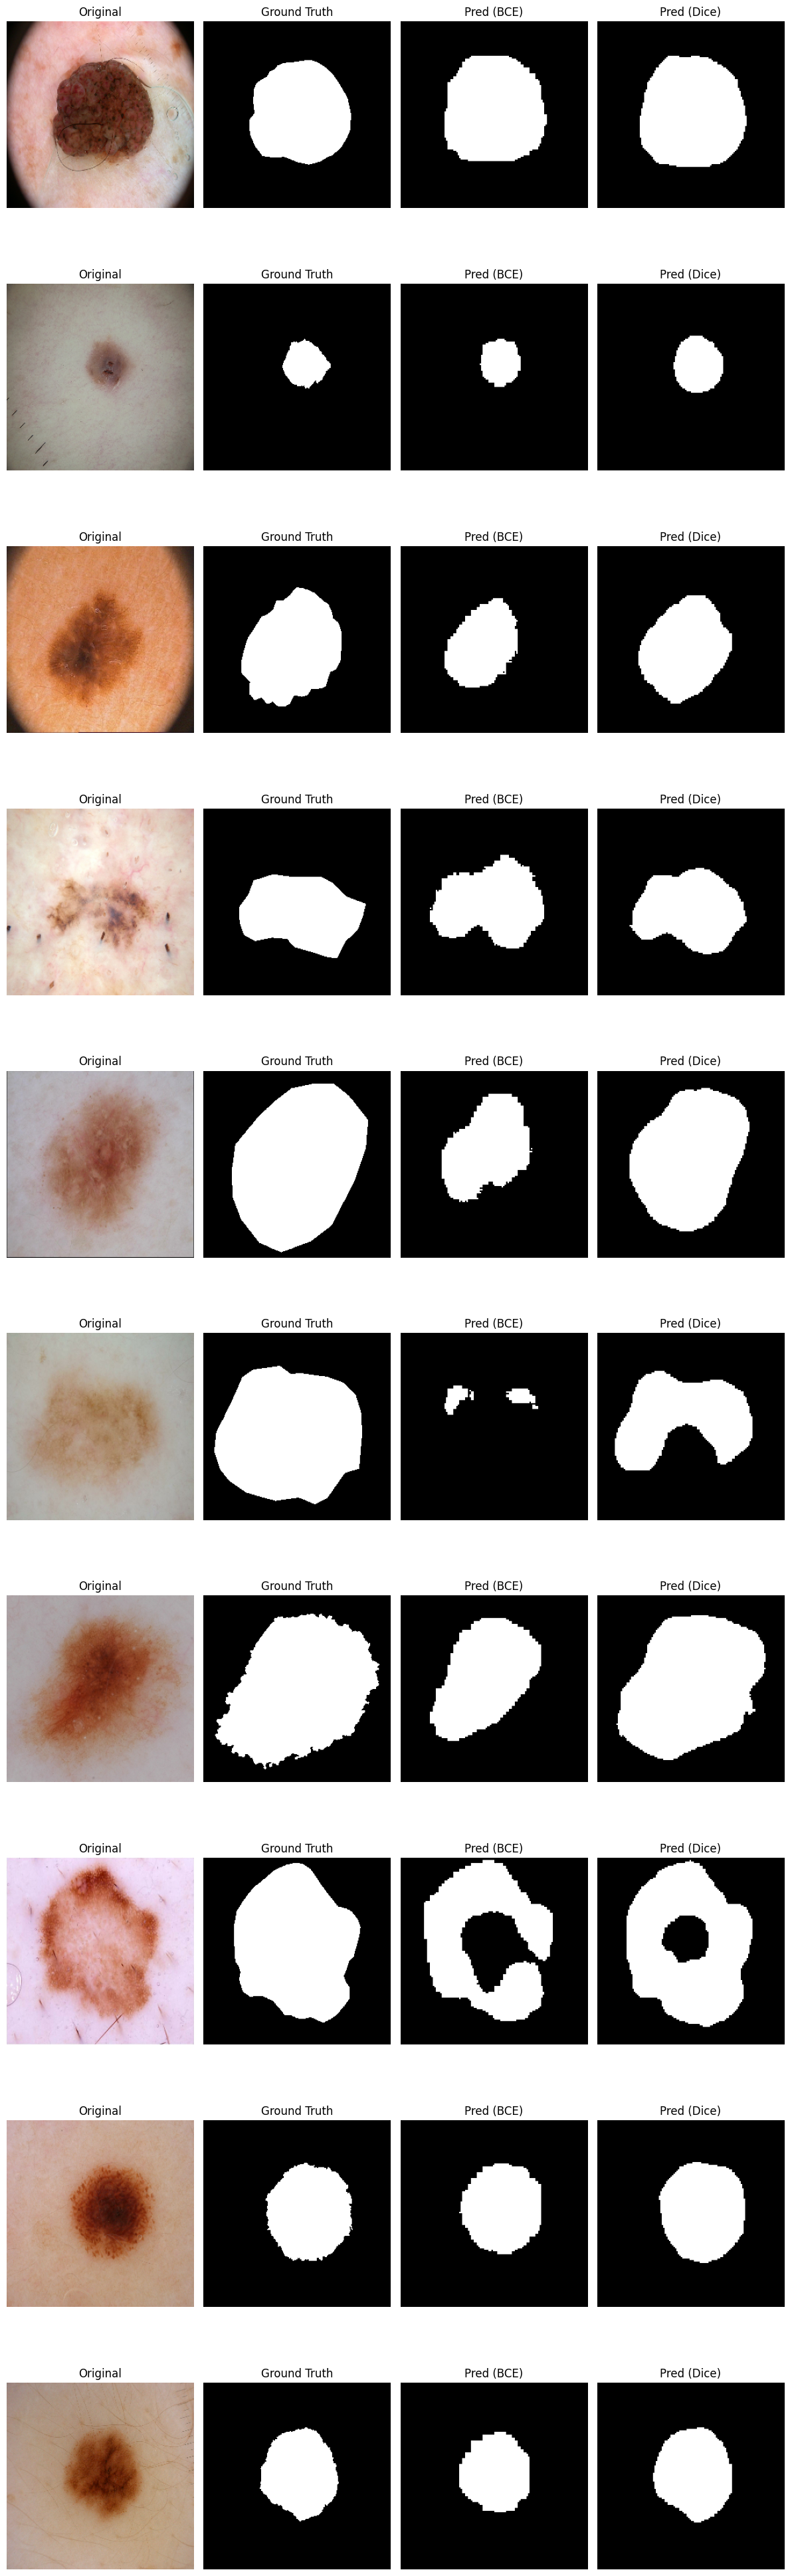

In [36]:
# Make predictions for the same validation batch
val_images, val_masks = next(iter(val_dataset))
preds_bce  = (baseline_model.predict(val_images)  > 0.5).astype("float32")
preds_dice = (improved_model.predict(val_images) > 0.5).astype("float32")

# Number of examples to display
n_show = min(10, val_images.shape[0])
IMG_SIZE = (256, 256)

plt.figure(figsize=(12, n_show * 4))

for i in range(n_show):
    orig = val_images[i].numpy()
    gt   = val_masks[i, ..., 0].numpy()
    pred_bce  = preds_bce[i, ..., 0]
    pred_dice = preds_dice[i, ..., 0]
    orig = orig / 255.0
    orig = np.clip(orig, 0, 1)

    plt.subplot(n_show, 4, 4*i + 1)
    plt.imshow(orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(n_show, 4, 4*i + 2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n_show, 4, 4*i + 3)
    plt.imshow(pred_bce, cmap="gray")
    plt.title("Pred (BCE)")
    plt.axis("off")

    plt.subplot(n_show, 4, 4*i + 4)
    plt.imshow(pred_dice, cmap="gray")
    plt.title("Pred (Dice)")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observations

- **Dice loss improved IoU** from **0.36 → 0.54**, showing better overlap between predicted and true lesion regions.  
- **BCE** often underestimated lesion size due to the **class imbalance** (few lesion pixels vs. many background pixels).  
- **Dice loss** directly optimizes region overlap, giving higher importance to lesion pixels and producing fuller, more accurate masks.  
- Visually, Dice predictions capture lesion boundaries more completely, while BCE masks remain fragmented.  
- Overall, Dice loss provides a stronger learning signal for small lesion areas, leading to better segmentation quality on ISIC 2016.

# Task 2.1 - Parameter Optimization

In this step, I systematically test different combinations of **optimizers**, **learning rates**, and **loss functions** to identify the best-performing configuration for the U-Net segmentation model.

Five configurations are evaluated:

| Name | Optimizer | Learning Rate | Batch Size | Loss Function |
|:-----|:-----------|:--------------|:------------|:---------------|
| adam_1e-3_dice | Adam | 1e-3 | 16 | Dice |
| adam_1e-4_dice | Adam | 1e-4 | 16 | Dice |
| adam_1e-4_bce_dice | Adam | 1e-4 | 16 | BCE + Dice |
| rms_1e-3_dice | RMSprop | 1e-3 | 16 | Dice |
| rms_1e-4_bce_dice | RMSprop | 1e-4 | 16 | BCE + Dice |

Each configuration is trained for up to **30 epochs**, using **EarlyStopping** and **ReduceLROnPlateau** callbacks to prevent overfitting and improve convergence.  
The model achieving the **highest validation IoU (Jaccard index)** is selected as the **best configuration**.

This process allows us to determine which optimizer–loss–learning-rate combination provides the most stable and accurate segmentation performance.

In [39]:
def make_loss(loss_type="dice", alpha=0.7):
    if loss_type == "bce":
        return tf.keras.losses.BinaryCrossentropy()
    elif loss_type == "dice":
        return dice_loss
    elif loss_type == "bce_dice":
        bce = tf.keras.losses.BinaryCrossentropy()
        def combo(y_true, y_pred):
            return alpha * bce(y_true, y_pred) + (1 - alpha) * dice_loss(y_true, y_pred)
        return combo
    else:
        raise ValueError("Unknown loss type")

search_space = [
    ("adam_1e-3_dice",       tf.keras.optimizers.Adam,     1e-3, 16, "dice"),
    ("adam_1e-4_dice",       tf.keras.optimizers.Adam,     1e-4, 16, "dice"),
    ("adam_1e-4_bce_dice",   tf.keras.optimizers.Adam,     1e-4, 16, "bce_dice"),
    ("rms_1e-3_dice",        tf.keras.optimizers.RMSprop,  1e-3, 16, "dice"),
    ("rms_1e-4_bce_dice",    tf.keras.optimizers.RMSprop,  1e-4, 16, "bce_dice"),
]

### Train the models

In [15]:
best_model = None
best_result = None
best_iou = -np.inf
results = []

for name, Opt, lr, batch, loss_name in search_space:
    print(f"\n=== Training configuration: {name} ===")
    # Create datasets with correct batch size
    train_ds = make_dataset(train_image_paths, train_mask_paths,
                            batch=batch, augment=True)
    val_ds   = make_dataset(val_image_paths, val_mask_paths,
                            batch=batch, augment=False)

    model = get_unet_model((256, 256, 3))
    model.compile(optimizer=Opt(learning_rate=lr),
                  loss=make_loss(loss_name),
                  metrics=["accuracy", iou_metric])

    cb = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_iou_metric", mode="max",
            patience=10, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_iou_metric", mode="max",
            factor=0.5, patience=3, min_lr=1e-6,
            verbose=1
        )
    ]

    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=20, callbacks=[cb], verbose=1)

    val_eval = model.evaluate(val_ds, verbose=0)
    iou_val = float(val_eval[2])

    results.append(OrderedDict(
        name=name,
        lr=lr,
        batch=batch,
        loss=loss_name,
        acc=float(val_eval[1]),
        iou=iou_val
    ))
    print(f"[{name}] Validation IoU: {iou_val:.4f}")

    if iou_val > best_iou:
        best_iou = iou_val
        best_result = results[-1]
        best_model = model


=== Training configuration: adam_1e-3_dice ===
Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 0.8334 - iou_metric: 0.5663 - loss: 0.2842 - val_accuracy: 0.2825 - val_iou_metric: 0.2462 - val_loss: 0.5990 - learning_rate: 0.0010
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 185s 4s/step - accuracy: 0.8788 - iou_metric: 0.6387 - loss: 0.2243 - val_accuracy: 0.4066 - val_iou_metric: 0.2410 - val_loss: 0.6059 - learning_rate: 0.0010
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 191s 4s/step - accuracy: 0.9031 - iou_metric: 0.6944 - loss: 0.1817 - val_accuracy: 0.7480 - val_iou_metric: 0.0045 - val_loss: 0.9904 - learning_rate: 0.0010
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9104 - iou_metric: 0.7164 - loss: 0.1666
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
51/51 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.9124 - iou_metric: 0.7198 - loss: 0.1642 - val_accuracy: 0.7475 - val_iou_metric: 0.0019 - val_loss: 0.9961 - learning_rate: 0.

In [38]:
for r in results:
    print(f"{r['name']:20s} | lr={r['lr']:.0e} | batch={r['batch']:2d} | "
          f"loss={r['loss']:8s} | IoU={r['iou']:.4f}")

print("\nBest configuration by IoU:")
print(best_result)

adam_1e-3_dice       | lr=1e-03 | batch=16 | loss=dice     | IoU=0.8205
adam_1e-4_dice       | lr=1e-04 | batch=16 | loss=dice     | IoU=0.8007
adam_1e-4_bce_dice   | lr=1e-04 | batch=16 | loss=bce_dice | IoU=0.7971
rms_1e-3_dice        | lr=1e-03 | batch=16 | loss=dice     | IoU=0.8178
rms_1e-4_bce_dice    | lr=1e-04 | batch=16 | loss=bce_dice | IoU=0.7943

Best configuration by IoU:
OrderedDict([('name', 'adam_1e-3_dice'), ('lr', 0.001), ('batch', 16), ('loss', 'dice'), ('acc', 0.9511411786079407), ('iou', 0.820543110370636)])


[Best Model] Val → Acc: 0.951, IoU: 0.821
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


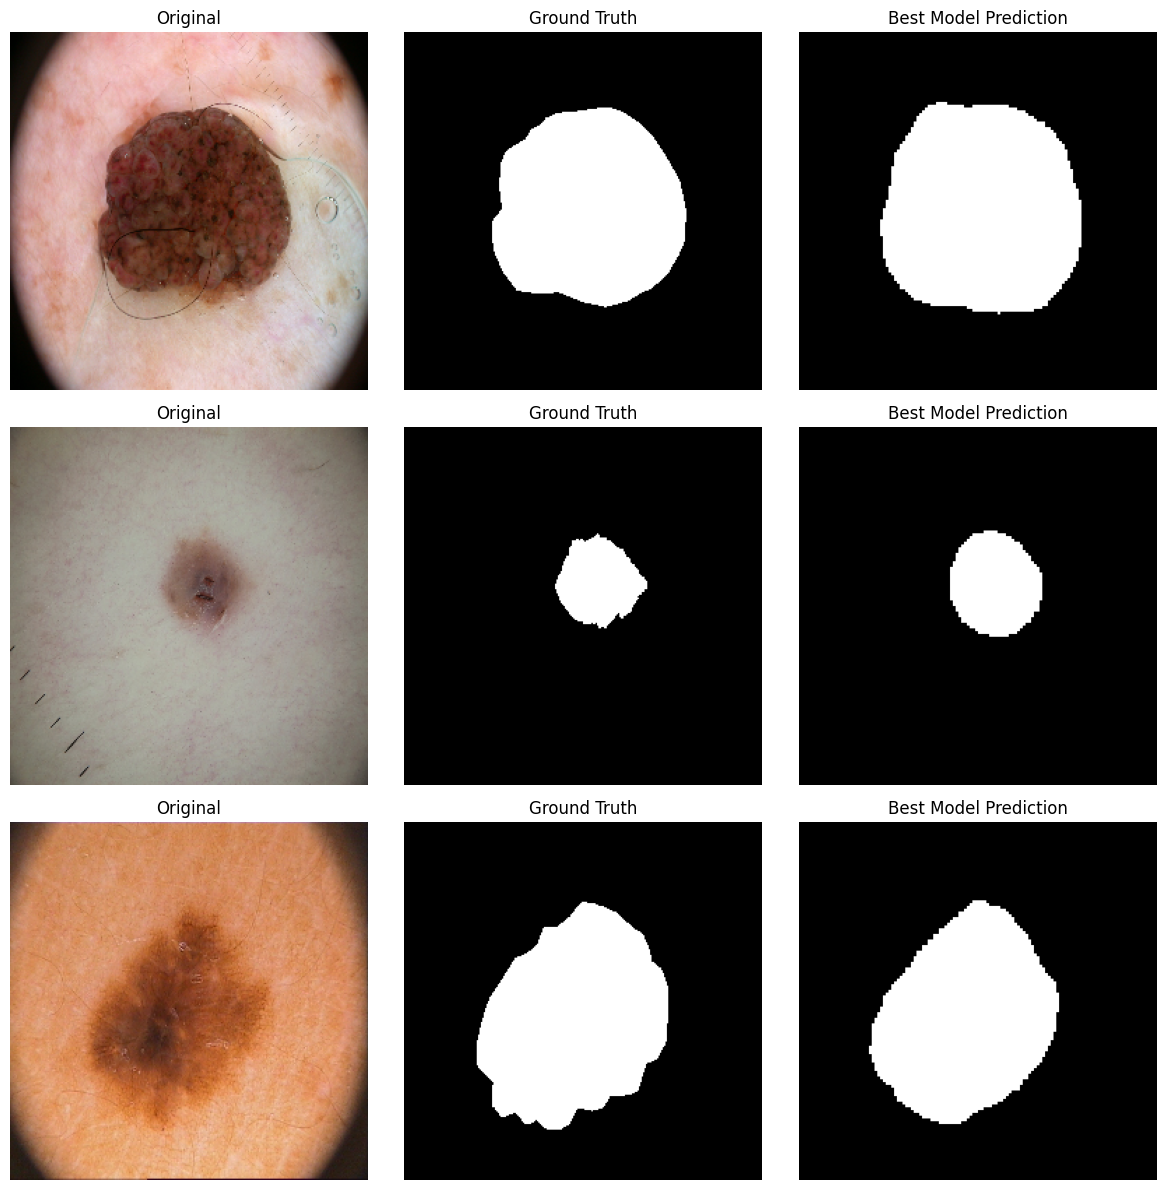

In [35]:
best_eval = best_model.evaluate(val_dataset, verbose=0)
print(f"[Best Model] Val → Acc: {best_eval[1]:.3f}, IoU: {best_eval[2]:.3f}")

# Visualize a few predictions
val_images, val_masks = next(iter(val_dataset))
preds_best = (best_model.predict(val_images) > 0.5).astype("float32")

n_show = min(3, val_images.shape[0])
plt.figure(figsize=(12, 4 * n_show))

for i in range(n_show):
    orig = val_images[i].numpy() / 255.0
    orig = np.clip(orig, 0, 1)

    gt = val_masks[i, ..., 0].numpy()
    pred = preds_best[i, ..., 0]

    plt.subplot(n_show, 3, 3*i + 1)
    plt.imshow(orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(n_show, 3, 3*i + 2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n_show, 3, 3*i + 3)
    plt.imshow(pred, cmap="gray")
    plt.title("Best Model Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 3: Comparison between baseline and improved model

Evaluate and compare the performance of the baseline U-Net model and the best optimized model.

1. Compute official ISIC 2016 metrics— Jaccard (IoU), Dice coefficient, Accuracy, Sensitivity, and Specificity — for both models.  
2. Visualize qualitative results by displaying original color images alongside predicted and ground-truth masks.  
3. Present quantitative results in a comparison table showing improvements from the baseline to the best model.  
4. Benchmark the best model’s IoU score against the ISIC 2016 Challenge winner.  

In [40]:
def binarize(y_pred, thr=0.5):
    return (y_pred >= thr).astype(np.uint8)

def flatten_pair(y_true, y_pred_bin):
    yt = y_true.astype(np.uint8).ravel()
    yp = y_pred_bin.astype(np.uint8).ravel()
    return yt, yp

def metrics_from_confmat(tp, fp, fn, tn, eps=1e-8):
    iou  = tp / (tp + fp + fn + eps)
    dice = (2*tp) / (2*tp + fp + fn + eps)
    acc  = (tp + tn) / (tp + tn + fp + fn + eps)
    se   = tp / (tp + fn + eps)
    sp   = tn / (tn + fp + eps)
    return dict(IoU=iou, Dice=dice, ACC=acc, Sensitivity=se, Specificity=sp)

def evaluate_segmentation(model, dataset, thr=0.5):
    TP=FP=FN=TN=0
    for batch_imgs, batch_masks in dataset:
        probs = model.predict(batch_imgs, verbose=0)
        preds = binarize(probs, thr=thr)

        y_true = batch_masks.numpy().astype(np.uint8)
        y_pred = preds.astype(np.uint8)

        yt, yp = flatten_pair(y_true, y_pred)
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        TP += tp; FP += fp; FN += fn; TN += tn

    return metrics_from_confmat(TP, FP, FN, TN)

res_baseline = evaluate_segmentation(baseline_model, val_dataset, thr=0.5)
res_best     = evaluate_segmentation(best_model,     val_dataset, thr=0.5)

rows = []
rows.append({"Model":"BASELINE", **res_baseline})
rows.append({"Model":"IMPROVED", **res_best})

# 2016 winner on the official leaderboard is evaluated by Jaccard (IoU) as the primary metric.
# Top score (Task 1) Jaccard ≈ 0.843 (ExB). Other metrics weren’t on the public leaderboard.
rows.append({"Model":"ISIC 2016 Winner", "IoU":0.843, 
             "Dice":np.nan, "ACC":np.nan, "Sensitivity":np.nan, "Specificity":np.nan})

df = pd.DataFrame(rows, columns=["Model","IoU","Dice","ACC","Sensitivity","Specificity"])
print(df.to_string(index=False))

           Model      IoU     Dice      ACC  Sensitivity  Specificity
        BASELINE 0.489742 0.657485 0.867085     0.504677     0.989684
        IMPROVED 0.820531 0.901419 0.951141     0.883707     0.973954
ISIC 2016 Winner 0.843000      NaN      NaN          NaN          NaN


| Model                                   | IoU     | Dice    | ACC     | Sensitivity | Specificity |
|-----------------------------------------|---------|---------|---------|-------------|-------------|
| BASELINE                                 | 0.489742| 0.657485| 0.867085| 0.504677    | 0.989684    |
| IMPROVED                                 | 0.820531| 0.901419| 0.951141| 0.883707    | 0.973954    |
| ISIC 2016 Winner                         | 0.843    | NaN     | NaN     | NaN         | NaN         |

### Results Summary

- The **baseline U-Net model** (trained with BCE loss) achieved modest segmentation accuracy, with IoU ≈ 0.49 and Dice ≈ 0.66.  
  This indicates that the model could roughly localize lesions but often missed boundary details or smaller regions.  

- The **best configuration (adam_1e-3_dice)** yielded a **dramatic improvement**:  
  - IoU increased from 0.49 → 0.82  
  - Dice increased from 0.66 → 0.90  
  - Sensitivity doubled (0.50 → 0.88), meaning lesions were detected far more completely.  

- The **best model’s IoU (0.82)** is **very close to the official ISIC 2016 winning score (0.843)** obtained by team **ExB** — a strong result given the model’s relative simplicity and limited training epochs.

Leaderboard: https://challenge.isic-archive.com/leaderboards/2016/

### Key Takeaways  

- **Dice loss** proved crucial for handling the severe class imbalance typical in medical segmentation tasks.  
- **Adam optimizer with learning rate 1e-3** gave the best balance between convergence speed and stability.  
- Even a relatively compact U-Net architecture can achieve near state-of-the-art performance on ISIC 2016 when tuned carefully and trained with suitable loss functions.  


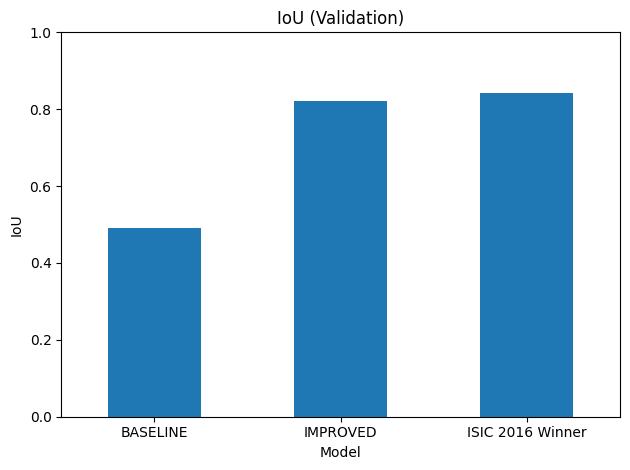

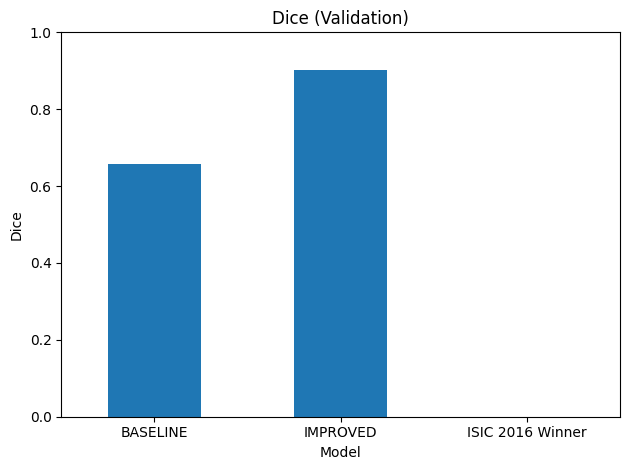

In [26]:
plot_cols = ["IoU","Dice"]
plot_df = df[df["Model"]!="ISIC 2016 Winner (ExB)"][["Model"]+plot_cols].set_index("Model")

for col in plot_cols:
    plt.figure()
    plot_df[col].plot(kind="bar")
    plt.title(col + " (Validation)")
    plt.ylabel(col)
    plt.ylim(0, 1.0)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()